In [8]:
def linearize_index_2d(x, y, shape):
    return y * shape[1] + x

dim: 16, idx: 8, unraveled: [tensor(8)]
dim: 16, idx: 0, unraveled: [tensor(8), tensor(8)]
[tensor(8), tensor(8)]


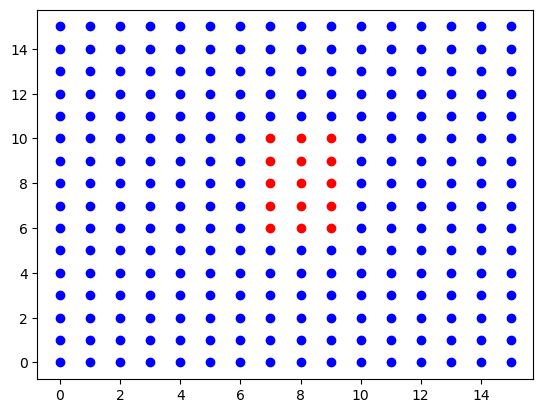

In [9]:
from architectures.utils import unravel_index
from matplotlib import pyplot as plt
import torch

patch_size = [16, 16]
kernel = [3, 5]

def compute_mask(b, h, q_idx, kv_idx):
    # unravel index
    q_x = q_idx % patch_size[1]; q_y = q_idx // patch_size[1]
    kv_x = kv_idx % patch_size[1]; kv_y = kv_idx // patch_size[1]

    # compute mask
    is_valid = (q_x - kv_x).abs() <= kernel[0] // 2
    is_valid &= (q_y - kv_y).abs() <= kernel[1] // 2
    return is_valid


q_idx = torch.tensor(linearize_index_2d(8, 8, patch_size))
for i in torch.arange(16*16):
    mask = compute_mask(1, 1, q_idx, i)
    if mask:
        plt.plot(i % 16, i // 16, 'ro')
    else:
        plt.plot(i % 16, i // 16, 'bo')
print(unravel_index(q_idx, patch_size))

dim: 16, idx: 33, unraveled: [tensor(0)]
dim: 16, idx: 2, unraveled: [tensor(0), tensor(1)]
[tensor(1), tensor(0)]


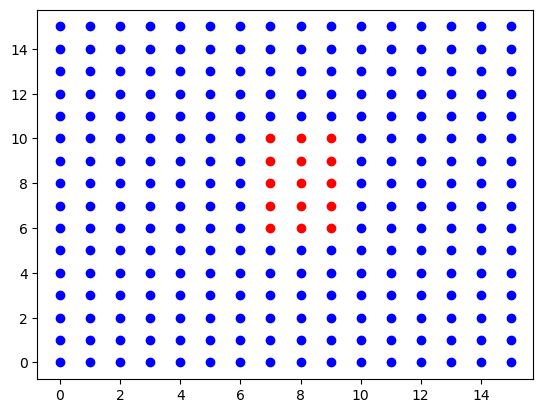

In [15]:
q_patch_size = [32, 32]
kv_patch_size = [16, 16]
kernel = [3, 5]
scale = 2

def compute_scale_mask(b, h, q_idx, kv_idx):
    # unravel index
    q_x = q_idx % q_patch_size[1]; q_y = q_idx // q_patch_size[1]
    kv_x = kv_idx % kv_patch_size[1]; kv_y = kv_idx // kv_patch_size[1]

    # normalize coordinates to [-1, 1]
    q_x = q_x / q_patch_size[1] * 2 - 1
    q_y = q_y / q_patch_size[0] * 2 - 1
    kv_x = kv_x / kv_patch_size[1] * 2 - 1
    kv_y = kv_y / kv_patch_size[0] * 2 - 1
    kernel_x = (kernel[0] / kv_patch_size[1]) * ((kv_patch_size[1] - 1) / kv_patch_size[1])
    kernel_y = (kernel[1] / kv_patch_size[0]) * ((kv_patch_size[0] - 1) / kv_patch_size[0])


    # align corners
    q_x *= (q_patch_size[1] - 1) / q_patch_size[1]
    q_y *= (q_patch_size[0] - 1) / q_patch_size[0]
    kv_x *= (kv_patch_size[1] - 1) / kv_patch_size[1]
    kv_y *= (kv_patch_size[0] - 1) / kv_patch_size[0]


    # compute mask
    is_valid = (q_x - kv_x).abs() <= kernel_x
    is_valid &= (q_y - kv_y).abs() <= kernel_y
    return is_valid


q_idx = torch.tensor(linearize_index_2d(16, 16, q_patch_size))
for i in torch.arange(16*16):
    mask = compute_scale_mask(1, 1, q_idx, i)
    if mask:
        plt.plot(i % 16, i // 16, 'ro')
    else:
        plt.plot(i % 16, i // 16, 'bo')
print(unravel_index(q_idx, patch_size))

dim: 16, idx: 8, unraveled: [tensor(8)]
dim: 16, idx: 0, unraveled: [tensor(8), tensor(8)]
[tensor(8), tensor(8)]


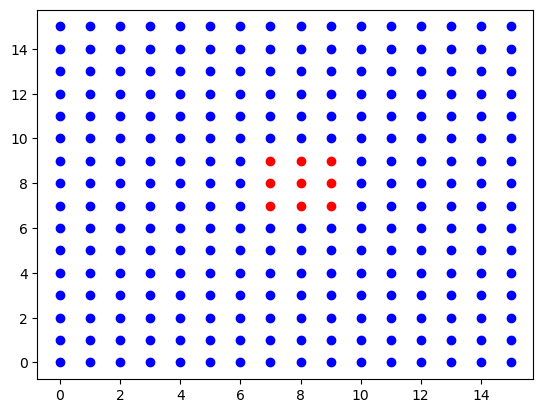

In [11]:
patch_size = [16, 16]
kernel = [3, 3]
dilation = 3

def compute_dilated_mask(b, h, q_idx, kv_idx):
    # unravel index
    q_x = q_idx % patch_size[1]; q_y = q_idx // patch_size[1]
    kv_x = kv_idx % patch_size[1]; kv_y = kv_idx // patch_size[1]

    # compute mask
    # is in receptive field
    is_valid = (q_x - kv_x).abs() <= (kernel[0] + (kernel[0] - 1) * (dilation - 1)) // 2
    is_valid &= (q_y - kv_y).abs() <= (kernel[1] + (kernel[1] - 1) * (dilation - 1)) // 2
    # is in dilation
    is_valid &= ((q_x - kv_x) % dilation == 0)
    is_valid &= ((q_y - kv_y) % dilation == 0)

    return is_valid


q_idx = torch.tensor(linearize_index_2d(8, 8, patch_size))
for i in torch.arange(16*16):
    mask = compute_mask(1, 1, q_idx, i)
    if mask:
        plt.plot(i % 16, i // 16, 'ro')
    else:
        plt.plot(i % 16, i // 16, 'bo')
print(unravel_index(q_idx, patch_size))

In [12]:
from torch.nn.attention import flex_attention
import torch

B, H, L, E = 1, 1, 16*16, 64
mask = flex_attention.create_block_mask(compute_dilated_mask, B, H, L, L, _compile=True, device='cpu')
my_flex_attn = torch.compile(flex_attention.flex_attention, dynamic=False) if False else flex_attention.flex_attention

In [13]:
x = torch.randn(B, H, L, E)
my_flex_attn(x, x, x, block_mask=mask)

tensor([[[[ 1.3485, -0.7183, -0.1725,  ..., -1.0232, -0.6158, -0.3267],
          [ 1.0755,  0.4784, -1.4655,  ..., -0.2463, -1.8845,  0.5569],
          [ 0.7727,  0.1280, -1.1876,  ...,  0.1592, -0.0978, -0.5070],
          ...,
          [ 0.6423,  1.6193,  0.9878,  ..., -0.4906, -2.2338,  1.8847],
          [ 0.5008, -2.2419,  0.1383,  ..., -0.9503,  0.6486,  0.1460],
          [-1.5806, -1.1359,  0.0377,  ..., -0.6312, -0.4728,  0.6119]]]])